In [5]:
import  sklearn
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import warnings
from sklearn import preprocessing
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import shap
import copy
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import time
import lightgbm as lgb
from sklearn.model_selection import KFold
import torch
import torch.optim as optim
from sklearn.ensemble import RandomForestRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy
import numpy as np
from xgboost import DMatrix, train
from sklearn.datasets import make_regression
import torch.optim as optim
np.random.seed(42)
torch.manual_seed(42)
warnings.filterwarnings("ignore")
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib
import pickle
import glob
import numpy as np
from scipy.stats import *
import xgboost as xgb
import torch.nn.functional as F
import numpy as np
from scipy.stats import mode
import copy
from torch.utils.data import Dataset, DataLoader
import torch
# from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
import pickle
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  
matplotlib.rcParams['axes.unicode_minus'] = False 
import os
import gc
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from flaml import AutoML

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import pickle
def set_seed(seed):
    import random
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)
from sklearn.utils import shuffle
import pickle

# Data generation

In [8]:


usingFeatures = [
    "IDW", "Lon", "Lat","LandCover",  "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",  "BuildingHeight90", "Pop", "NightLight",  "Aspect",
      "Hillshade", "Curvature", "ProfileCur", "PlanCur",  "DEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","Gain","NIR","RGB","SAR_VV","SAR_VH"
]


selected_features= ['BuildingHeight90', 'ForestHeight', 'ForestHeight10', 'ForestHeight30', 
                    'DEM', 'HEL', 'ForestCoverage', 'Aspect', 'Hillshade', 'NIR', 'deltMinDEM', 'RGB', 'SAR_VV', 'Curvature', 'FCLoss']


train_data,val_data,test_data,train_labels,val_labels,test_labels=None,None,None,None,None,None
test_DEM,test_HRDEM,test_FABDEM,test_FathomDEM,test_Pid,test_GEDTM30=None,None,None,None,None,None

train_loader,val_loader,test_loader=None,None,None
featureNum,landformArray=None,None



"""----------------------训练数据生成---------------------"""
     
def genTrainingData_HRDEM(numpy_data,cols_names,selected_features,mean_std_path, IsEmpty=True):
    trainingdata_num=numpy_data.shape[0]

    data_reshaped = numpy_data.reshape(-1, numpy_data.shape[1]*numpy_data.shape[2], numpy_data.shape[3])  
    data_final_2d = data_reshaped.reshape(-1, numpy_data.shape[3]) 
  
    df = pd.DataFrame(data_final_2d, columns=cols_names)

    df['DEM_HR'] = df['DEM'] - df['HRDEM'] 
    


    if IsEmpty:
        """ ------- 将Pid字段为0的,全部字段都设置为Nodata ----- """
        df.loc[df['LandCover'].isin([187,210,0]), "Pid"] = -1  #xxx

        df.loc[(df['DEM_HR'] < -200) | (df['DEM_HR'] > 200), "Pid"] = -1     #xxx

        df.loc[df['Pid'] == -1, :] = np.nan


    HRDEMArray = np.array(df['HRDEM'])
    df = df.drop('HRDEM', axis=1)

    labelArray = np.array(df['DEM_HR'])
    df = df.drop('DEM_HR', axis=1)

    PidArray = np.array(df['Pid'])
    df = df.drop('Pid', axis=1)

   

    """ Forest canopy height (0-60 heights 101 water  102 snow/ice  103 Nodata) """
    if 'ForestHeight30' in df.columns.tolist():
        df.loc[(df['ForestHeight30'] > 100) | (df['ForestHeight30'] < 0), 'ForestHeight30'] = 0


    FABDEMArray = np.array(df['FABDEM'])
    df = df.drop('FABDEM', axis=1)

    GEDTM30Array = np.array(df['GEDTM30'])*10
    df = df.drop('GEDTM30', axis=1)

    FathomDEMArray = np.array(df['FathomDEM'])
    df = df.drop('FathomDEM', axis=1)

    DEMArray = np.array(df['DEM'])


    df=df[selected_features]
    features = np.array(df)

    #---------------- ZScore 归一化---------------------

    selected_indices = [usingFeatures.index(feat) for feat in selected_features]

    mean_val_all=np.load(mean_std_path)['mean'] 
    std_val_all=np.load(mean_std_path)['std']
    mean_val = mean_val_all[0, selected_indices, 0, 0] 
    std_val = std_val_all[0, selected_indices, 0, 0]   

    for i in range(features.shape[1]):  
        features[:, i] = (features[:, i] - mean_val[i]) / std_val[i]

    input_features=features


    """ 
    pandas -> width x height 
    """
    reshape_features = input_features.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2], input_features.shape[1])
    reshape_features=np.transpose(reshape_features,(0,3,1,2))

    
    mask = ~np.isnan(reshape_features).any(axis=(1, 2, 3)) 
    reshape_features = reshape_features[mask]  


    reshape_labels = labelArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2]) 
    reshape_labels=reshape_labels[mask]
    reshape_Pids = PidArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_Pids=reshape_Pids[mask]
    reshape_FABDEM = FABDEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])  
    reshape_FABDEM=reshape_FABDEM[mask]
    reshape_GEDTM30DEM = GEDTM30Array.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])  
    reshape_GEDTM30=reshape_GEDTM30DEM[mask]
    reshape_FathomDEM = FathomDEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_FathomDEM=reshape_FathomDEM[mask]  
    reshape_DEM = DEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_DEM=reshape_DEM[mask]
    reshape_HRDEM = HRDEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_HRDEM=reshape_HRDEM[mask]


    global featureNum
    featureNum=input_features.shape[1]
    global train_data,val_data,test_data
    global train_labels,val_labels,test_labels
    global test_DEM,test_HRDEM,test_FABDEM,test_FathomDEM,test_Pid,test_GEDTM30
  
    test_data = reshape_features
    test_labels = reshape_labels

    test_DEM = reshape_DEM
    test_HRDEM = reshape_HRDEM
    test_FABDEM= reshape_FABDEM
    test_GEDTM30= reshape_GEDTM30
    test_FathomDEM= reshape_FathomDEM
    test_Pid= reshape_Pids


def genTrainingData_HRDEM_nofilter(numpy_data,cols_names):
    trainingdata_num=numpy_data.shape[0]

    data_reshaped = numpy_data.reshape(-1, numpy_data.shape[1]*numpy_data.shape[2], numpy_data.shape[3])  
    data_final_2d = data_reshaped.reshape(-1, numpy_data.shape[3]) 
  
    df = pd.DataFrame(data_final_2d, columns=cols_names)
    
    
    df = df.drop('LandForm', axis=1)

    df = df.drop('LandCover', axis=1)
    
    df['DEM_HR'] = df['DEM'] - df['HRDEM'] 

    HRDEMArray = np.array(df['HRDEM'])
    df = df.drop('HRDEM', axis=1)

    labelArray = np.array(df['DEM_HR'])
    df = df.drop('DEM_HR', axis=1)


    PidArray = np.array(df['Pid'])
    df = df.drop('Pid', axis=1)


    """ Forest canopy height (0-60 heights 101 water  102 snow/ice  103 Nodata) """
    if 'ForestHeight30' in df.columns.tolist():
        df.loc[(df['ForestHeight30'] > 100) | (df['ForestHeight30'] < 0), 'ForestHeight30'] = 0

    # Bias for FABDEM and HQTPDEM
    FABDEMArray = np.array(df['FABDEM'])
    df = df.drop('FABDEM', axis=1)

    GEDTM30Array = np.array(df['GEDTM30'])
    df = df.drop('GEDTM30', axis=1)

    FathomDEMArray = np.array(df['FathomDEM'])
    df = df.drop('FathomDEM', axis=1)

    DEMArray = np.array(df['DEM'])


    df=df[usingFeatures]
    features = np.array(df)
   
    input_features = preprocessing.StandardScaler().fit_transform(features)  


    """ 
    pandas -> width x height 
    """
    reshape_features = input_features.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2], input_features.shape[1])
    reshape_features=np.transpose(reshape_features,(0,3,1,2))

    
    mask = ~np.isnan(reshape_features).any(axis=(1, 2, 3)) 
    reshape_features = reshape_features[mask]  
 

    reshape_labels = labelArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2]) 
    reshape_labels=reshape_labels[mask]
    reshape_Pids = PidArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_Pids=reshape_Pids[mask]
    reshape_FABDEM = FABDEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])  
    reshape_FABDEM=reshape_FABDEM[mask]
    reshape_GEDTM30DEM = GEDTM30Array.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])  
    reshape_GEDTM30=reshape_GEDTM30DEM[mask]
    reshape_FathomDEM = FathomDEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_FathomDEM=reshape_FathomDEM[mask]  
    reshape_DEM = DEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_DEM=reshape_DEM[mask]
    reshape_HRDEM = HRDEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_HRDEM=reshape_HRDEM[mask]

    global test_data,test_labels
    global test_DEM,test_HRDEM,test_FABDEM,test_FathomDEM,test_Pid,test_GEDTM30

    test_data = reshape_features
    test_labels = reshape_labels

    test_DEM = reshape_DEM
    test_HRDEM = reshape_HRDEM
    test_FABDEM= reshape_FABDEM
    test_GEDTM30= reshape_GEDTM30
    test_FathomDEM= reshape_FathomDEM
    test_Pid= reshape_Pids

    print(f"Training Training data: {test_data.shape} ")
    
    


def genTrainingData_ICESat(numpy_data,cols_names,selected_features,mean_std_path,IsEmpty=True):
    trainingdata_num=numpy_data.shape[0]

    data_reshaped = numpy_data.reshape(-1, numpy_data.shape[1]*numpy_data.shape[2], numpy_data.shape[3])  
    data_final_2d = data_reshaped.reshape(-1, numpy_data.shape[3]) 
  
    df = pd.DataFrame(data_final_2d, columns=cols_names)
    
    if IsEmpty:
        df.loc[df['LandCover'].isin([187,210,0]), "Pid"] = -1
        df.loc[df['Pid'] == -1, :] = np.nan

    PidArray = np.array(df['Pid'])
    DEMArray = np.array(df['DEM'])

    df=df[selected_features]
    features = np.array(df)


    selected_indices = [usingFeatures.index(feat) for feat in selected_features]

    mean_val_all=np.load(mean_std_path)['mean'] 
    std_val_all=np.load(mean_std_path)['std']
    mean_val = mean_val_all[0, selected_indices, 0, 0] 
    std_val = std_val_all[0, selected_indices, 0, 0]   
    # features.shape[1] is the number of selected features
    for i in range(features.shape[1]):  
        features[:, i] = (features[:, i] - mean_val[i]) / std_val[i]

    input_features=features



    reshape_features = input_features.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2], input_features.shape[1])
    reshape_features=np.transpose(reshape_features,(0,3,1,2))

    
    mask = ~np.isnan(reshape_features).any(axis=(1, 2, 3))
    reshape_features = reshape_features[mask] 

    reshape_Pids = PidArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_Pids=reshape_Pids[mask] 
    reshape_DEM = DEMArray.reshape(trainingdata_num, numpy_data.shape[1], numpy_data.shape[2])
    reshape_DEM=reshape_DEM[mask]


    global featureNum
    featureNum=input_features.shape[1]
    global train_data,val_data,test_data
    global train_labels,val_labels,test_labels
    global test_DEM,test_HRDEM,test_FABDEM,test_FathomDEM,test_Pid,test_GEDTM30
    global X_train_map_d,X_val_map_d,X_test_map_d
    global y_train_map_d,y_val_map_d,y_test_map_d
    

    test_data = reshape_features
    test_DEM = reshape_DEM
    test_Pid= reshape_Pids




# Common methods

In [9]:
"""
Slope and Curvature 
"""
def compute_slope_curvature_rmse(Numpy_HRDEM, Numpy_CorDEM, cellsize_x=30, cellsize_y=30):

    def calculate_slope_curvature(dem, cellsize_x, cellsize_y):
    
        a = dem[:, :-2, :-2]  
        b = dem[:, :-2, 1:-1] 
        c = dem[:, :-2, 2:] 
        d = dem[:, 1:-1, :-2] 
        e = dem[:, 1:-1, 1:-1] 
        f = dem[:, 1:-1, 2:]  
        g = dem[:, 2:, :-2]
        h = dem[:, 2:, 1:-1]
        i = dem[:, 2:, 2:] 

        #  dz/dx
        dz_dx = ((c + 2 * f + i) - (a + 2 * d + g)) / (8 * cellsize_x)
        #  dz/dy
        dz_dy = ((g + 2 * h + i) - (a + 2 * b + c)) / (8 * cellsize_y)

      
        rise_run = np.sqrt(dz_dx ** 2 + dz_dy ** 2)
        slope = np.arctan(rise_run) * 57.29578  

    
        curvature = dz_dx ** 2 + dz_dy ** 2  

        return slope, curvature

 
    slope_ref, curvature_ref = calculate_slope_curvature(Numpy_HRDEM, cellsize_x, cellsize_y)
  
    slope_est, curvature_est = calculate_slope_curvature(Numpy_CorDEM, cellsize_x, cellsize_y)


    slope_rmse = np.sqrt(np.mean((slope_est - slope_ref) ** 2))
    curvature_rmse = np.sqrt(np.mean((curvature_est - curvature_ref) ** 2))

    return slope_rmse, curvature_rmse



# Models

## Unet-CNN

In [10]:

import torch.nn as nn
class DoubleConv(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UpCat(nn.Module):

    def __init__(self, in_ch_up, up_out_ch, skip_ch, conv_out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch_up, up_out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(up_out_ch + skip_ch, conv_out_ch)

    def forward(self, x_up, x_skip):
        x = self.up(x_up)
        x = torch.cat([x, x_skip], dim=1)
        return self.conv(x)

class Unet_CNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

 
        self.enc1 = DoubleConv(in_channels, 61)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(61, 154)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(154, 388)
        self.pool3 = nn.MaxPool2d(2)


        self.bottleneck = DoubleConv(388, 776)

        self.up3 = UpCat(in_ch_up=776, up_out_ch=388, skip_ch=388, conv_out_ch=388)
        self.up2 = UpCat(in_ch_up=388, up_out_ch=154, skip_ch=154, conv_out_ch=154)

       
        self.up1 = UpCat(in_ch_up=154, up_out_ch=61,  skip_ch=61,  conv_out_ch=61)


        self.conv_out = nn.Conv2d(61, 1, kernel_size=1)

 
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
   
        e1 = self.enc1(x)              # -> 61
        e2 = self.enc2(self.pool1(e1)) # -> 154
        e3 = self.enc3(self.pool2(e2)) # -> 388

        # Bottleneck
        b  = self.bottleneck(self.pool3(e3))  # -> 776

   
        d3 = self.up3(b,  e3)  # 776 -> up 388, cat 388 => 776 -> conv 388
        d2 = self.up2(d3, e2)  # 388 -> up 154, cat 154 => 308 -> conv 154
        d1 = self.up1(d2, e1)  # 154 -> up 61,  cat 61  => 122 -> conv 61

        out = self.conv_out(d1)        # -> 1
        return out.squeeze(1)          #

## Proposed

In [11]:
from timm.models.swin_transformer import SwinTransformerBlock

class SwinEncoderBlock(nn.Module):
    def __init__(self, in_channels,  num_heads=4, 
                 input_resolution=(64, 64), use_shift=True):
        super().__init__()
        self.input_resolution = input_resolution
        
        window_size = input_resolution[0]

        embed_dim=  in_channels
        
        self.use_shift = use_shift

        self.norm1 = nn.LayerNorm(embed_dim)

        self.swin_block = SwinTransformerBlock(
            dim=embed_dim,
            num_heads=num_heads,
            input_resolution=input_resolution,
            window_size=window_size,
            shift_size=0,
            mlp_ratio=4.0,
            qkv_bias=True,
            norm_layer=nn.LayerNorm
            
        )

    def forward(self, x):
        B, C, H, W = x.shape
        assert (H, W) == self.input_resolution, f"Expected input_resolution {(H, W)}, but got {(H, W)}"

        x_embed = x.permute(0, 2, 3, 1).contiguous()  # (B, H, W, C)
        x_embed = self.norm1(x_embed)
        x_attn = self.swin_block(x_embed)                   # (B, H, W, C)
        out = x_attn.permute(0, 3, 1, 2).contiguous()    # (B, embed_dim, H, W)
                  
        return out + x   


#--------------- ResidualBlock-----------------
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # shortcut for channel match
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)
        return out



class SEModule(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEModule, self).__init__()
        self.fc1 = nn.Linear(channels, channels // reduction, bias=False)
        self.fc2 = nn.Linear(channels // reduction, channels, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.size()
        y = x.view(b, c, -1).mean(dim=2)  
        y = self.fc1(y)
        y = self.relu(y)
        y = self.fc2(y)
        y = self.sigmoid(y).view(b, c, 1, 1)
        return x * y



#--------------- UpsampleBlock-----------------
class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, upscale_factor=2):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels * (upscale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.pixel_shuffle(x)
        x = self.relu(x)
        return x

class Unet_512_SwinEncoderBlock_SEBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

  
        self.encoder1 = nn.Sequential(ResidualBlock(in_channels, 64), SwinEncoderBlock(in_channels=64,input_resolution=(64, 64)),SEModule(channels=64))
        self.pool1 = nn.MaxPool2d(2)
        self.encoder2 = nn.Sequential(ResidualBlock(64, 128), SwinEncoderBlock(in_channels=128,input_resolution=(32, 32)),SEModule(channels=128))
        self.pool2 = nn.MaxPool2d(2)
        self.encoder3 = nn.Sequential(ResidualBlock(128, 256), SwinEncoderBlock(in_channels=256,input_resolution=(16, 16)),SEModule(channels=256))
        self.pool3 = nn.MaxPool2d(2)
        self.encoder4 = nn.Sequential(ResidualBlock(256, 512), SwinEncoderBlock(in_channels=512,input_resolution=(8, 8)),SEModule(channels=512))
        self.pool4 = nn.MaxPool2d(2)  

   
        self.up4 = UpsampleBlock(512, 512)
        self.up3 = UpsampleBlock(512, 256)
        self.up2 = UpsampleBlock(256, 128)
        self.up1 = UpsampleBlock(128, 64)

        self.decoder4 = ResidualBlock(512 * 2, 512)
        self.decoder3 = ResidualBlock(256 * 2, 256)
        self.decoder2 = ResidualBlock(128 * 2, 128)
        self.decoder1 = ResidualBlock(64 * 2, 64)

        self.conv_out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):

        enc1 = self.encoder1(x)                   # 64x64
        enc2 = self.encoder2(self.pool1(enc1))    # 32x32
        enc3 = self.encoder3(self.pool2(enc2))    # 16x16
        enc4 = self.encoder4(self.pool3(enc3))    # 8x8

        bottom = self.pool4(enc4)                 # 4x4 


        dec4 = self.up4(bottom)                   # 8x8
        dec4 = torch.cat((dec4, enc4), dim=1)     # 
        dec4 = self.decoder4(dec4)               
        dec3 = self.up3(dec4)                     # 16x16
        dec3 = torch.cat((dec3, enc3), dim=1)    
        dec3 = self.decoder3(dec3)               

        dec2 = self.up2(dec3)                     # 32x32
        dec2 = torch.cat((dec2, enc2), dim=1)    
        dec2 = self.decoder2(dec2)               

        dec1 = self.up1(dec2)                     # 64x64
        dec1 = torch.cat((dec1, enc1), dim=1)     
        dec1 = self.decoder1(dec1)              

        out = self.conv_out(dec1)                 
        out = out.squeeze(1)                    
        return out

# Predictions

In [12]:
import numpy as np
from osgeo import gdal

def AssignValuesByPixelID(input_raster_path, output_raster_path, pid_array, value_array):
    dataset = gdal.Open(input_raster_path, gdal.GA_ReadOnly)
    band = dataset.GetRasterBand(1)
    pixel_array = band.ReadAsArray()
    nodata = band.GetNoDataValue()



    if nodata is not None:
        pixel_array = np.where(pixel_array == nodata, 0, pixel_array)

    pixel_id_array = pixel_array.astype(np.int32)

 
    lut_size = pixel_id_array.max() + 1
    
    lut = np.full(lut_size, nodata, dtype=np.float32)

    
    pid_array = pid_array.astype(np.int32)


    lut[pid_array] = value_array


    mapped_array = lut[pixel_id_array]


    driver = gdal.GetDriverByName('GTiff')
    outDataset = driver.Create(output_raster_path,
                               pixel_id_array.shape[1], pixel_id_array.shape[0],
                               1, gdal.GDT_Float32)
    outDataset.SetGeoTransform(dataset.GetGeoTransform())
    outDataset.SetProjection(dataset.GetProjection())
    outBand = outDataset.GetRasterBand(1)
    outBand.WriteArray(mapped_array)
    outBand.SetNoDataValue(nodata)
    outBand.FlushCache()

    dataset, band, outDataset, outBand = None, None, None, None
    return output_raster_path


"""
Validation for ICESat Areas
"""
def predictModel_ExportDEM_ICESat(model,loadModel,batchsize,PidRaster,out_NSCNN): 
    
    test_dataset = TensorDataset(test_data, test_data)
    test_loader = DataLoader(test_dataset, batch_size=batchsize, shuffle=False)
        
    test_Pid_1d=test_Pid.flatten()

    checkpoint = torch.load(loadModel)
    
    model.load_state_dict(checkpoint['model_state_dict'])  
    

    model.eval() 
    
    all_preds,all_labels=[],[]
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            preds = model(batch_X)
            all_preds.append(preds.cpu())
     

    y_pred = torch.cat(all_preds, dim=0)
    
    corrected_DEM=test_DEM-y_pred.numpy()
    corrected_DEM_1d=corrected_DEM.flatten()

    
    AssignValuesByPixelID(input_raster_path=PidRaster, output_raster_path=out_NSCNN, pid_array=test_Pid_1d, value_array=corrected_DEM_1d)


def predictCNN(model,loadModel): 
    global test_data, test_labels
    test_dataset = TensorDataset(test_data, test_labels)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
        
    checkpoint = torch.load(loadModel)
    
    model.load_state_dict(checkpoint['model_state_dict'])  
    
    model.eval()  

    all_preds,all_labels=[],[]
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X=batch_X.cuda()
            batch_y=batch_y.cuda()

            preds = model(batch_X)
            all_preds.append(preds.cpu())
            all_labels.append(batch_y.cpu())


    y_pred = torch.cat(all_preds, dim=0)
    y_true = torch.cat(all_labels, dim=0)

    RMSE_NSCNN = (nn.functional.mse_loss(y_pred, y_true, reduction='mean').item())**0.5
    slope_rmse_NSCNN, curvature_rmse_NSCNN = compute_slope_curvature_rmse(test_HRDEM, test_DEM-y_pred.numpy())
    print(f"--- RMSE  Elevation: {RMSE_NSCNN:0.2f},  Slope: {slope_rmse_NSCNN:0.2f}, Curvature: {curvature_rmse_NSCNN:0.4f}")

    return y_pred.numpy().flatten()

"""
ML
"""
def predML_Models(test_data_2d,test_labels_1d,modelPath):

    with open(modelPath, "rb") as f:
        automl = pickle.load(f)

    prediction_test_1d = automl.predict(test_data_2d)
    
    predicted_rmse = np.sqrt(mean_squared_error(test_labels_1d, prediction_test_1d))
    B,H,W=test_HRDEM.shape
    pred_BHW = prediction_test_1d.reshape(B, H, W)
    slope_rmse, curvature_rmse=compute_slope_curvature_rmse(test_HRDEM, test_DEM-pred_BHW, cellsize_x=30, cellsize_y=30)
    print(f"----- RMSE--- Elevation:{predicted_rmse:0.2f}   Slope:{slope_rmse:0.2f}   Curvature:{curvature_rmse:0.4f} ")
    print()

    return prediction_test_1d





def predANN(test_data_2d,test_labels_1d,modelPath):

    print("ANN...........")

    with open(modelPath, 'rb') as f:
        best_model = pickle.load(f)
            
    batch_size = 10000
    results = []
    for i in range(0, len(test_data_2d), batch_size):
        batch = test_data_2d[i:i+batch_size]
        batch_pred = best_model.predict(batch)
        results.append(batch_pred)
    prediction_test_1d = np.concatenate(results)

    predicted_rmse = np.sqrt(mean_squared_error(test_labels_1d, prediction_test_1d))
    print(f"-----Raw RMSE--- Elevation:{predicted_rmse:0.2f}  ")

    return prediction_test_1d



    

def exportPredErrorToDEM(predError_1d,PidRaster,savePath): 
    
    test_Pid_1d=test_Pid.flatten()
    test_DEM_1d=test_DEM.flatten()
    
    corrected_DEM_1d=test_DEM_1d-predError_1d
 
    AssignValuesByPixelID(input_raster_path=PidRaster, output_raster_path=savePath, pid_array=test_Pid_1d, value_array=corrected_DEM_1d)




import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'Microsoft YaHei'

def DrawFigure(y_pred_err, y_true_err, title, imp, sample_frac=0.1, random_state=42):
 
    err_all = y_true_err - y_pred_err
    me = np.mean(err_all)
    mae = np.mean(np.abs(err_all))
    rmse = np.sqrt(np.mean(err_all**2))
    sd = np.std(err_all, ddof=1)
    ss_res = np.sum(err_all**2)
    ss_tot = np.sum((y_true_err - np.mean(y_true_err))**2)
    r2 = 1 - ss_res / ss_tot


    np.random.seed(random_state)
    n_total = len(y_pred_err)
    n_sample = max(1, int(n_total * sample_frac))
    idx_sample = np.random.choice(n_total, size=n_sample, replace=False)
    x = y_pred_err[idx_sample]
    y = y_true_err[idx_sample]

    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    slope, intercept = np.polyfit(y_pred_err, y_true_err, 1)
    y_reg = slope * x + intercept


    plt.figure(figsize=(8, 6), dpi=100)
    sc = plt.scatter(
        x, y, c=z, cmap='RdYlBu_r',
        s=15, alpha=0.7, edgecolors='none'
    )
    cbar = plt.colorbar(sc)
    cbar.set_label('Frequency', fontsize=14)
    cbar.ax.tick_params(labelsize=10)

    lims = [
        np.min([plt.xlim()[0], plt.ylim()[0]]),
        np.max([plt.xlim()[1], plt.ylim()[1]])
    ]
    plt.plot(lims, lims, '--', color='red', label='1:1 line', linewidth=0.8)
    plt.plot(x, y_reg, '-', color='black', label='Regression Line', linewidth=1.7)

    plt.xlabel('Predicted elevation error (m)')
    plt.ylabel('Reference elevation error (m)')
    plt.legend(loc='upper left')

    textstr = '\n'.join([
        r'$R^2=%.2f$    '   % r2,
        r'$ME=%.2f$ m' % me,
        r'$MAE=%.2f$ m' % mae,
        r'$RMSE=%.2f$ m' % rmse,
        r'$SD=%.2f$ m'  % sd,
        r'$RI(RMSE)=%.2f$ %%'  % imp
    ])
    plt.text(
        0.95, 0.05, textstr,
        transform=plt.gca().transAxes,
        fontsize=14,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()





In [15]:
test_labels_1d,test_ATL_1d,test_DEM_1d,test_FABDEM_1d,test_Fathom_1d,test_GEDTM30_1d=None,None,None,None,None,None
raw_rmse,raw_slopeRMSE,raw_curvatureRMSE=None,None,None
train_data_2d,val_data_2d,test_data_2d,train_labels_1d,val_labels_1d=None,None,None,None,None
from sklearn.utils import shuffle

npzFolder=r"DataModels"  
mean_std_path=r"DataModels/mean_std.npz"

label_size=64

label_area="NewZeeLand_nowater"

testPath_1=os.path.join(npzFolder,f"{label_area}_test_HM_{label_size}.npz")
otherPath_1=os.path.join(npzFolder,f"{label_area}_other_HM_{label_size}.npz")

label_area="America_nowater"

testPath_2=os.path.join(npzFolder,f"{label_area}_test_HM_{label_size}.npz")
otherPath_2=os.path.join(npzFolder,f"{label_area}_other_HM_{label_size}.npz")

label_area="European_nowater"

testPath_3=os.path.join(npzFolder,f"{label_area}_test_HM_{label_size}.npz")
otherPath_3=os.path.join(npzFolder,f"{label_area}_other_HM_{label_size}.npz")




def getTrainingData_2d(paths, mean_std_path,IsShuffle=False):
    

    selected_indices = [usingFeatures.index(feat) for feat in selected_features]
    
    mean_val_all=np.load(mean_std_path)['mean']
    std_val_all=np.load(mean_std_path)['std']

    mean_val = mean_val_all[0, selected_indices, 0, 0]  # shape: (num_selected_features,)
    std_val = std_val_all[0, selected_indices, 0, 0]    # shape: (num_selected_features,)

    all_data = []
    all_labels = []

    for path in paths:
        loaded = np.load(path)
        data = loaded['arr1'][:, selected_indices, :, :]  # 选取对应特征的数据
        labels = loaded['arr2']

        for i in range(data.shape[1]):  # data.shape[1] is the number of features (channels)
            data[:, i, :, :] = (data[:, i, :, :] - mean_val[i]) / std_val[i]

        all_data.append(data)
        all_labels.append(labels)

    data = np.concatenate(all_data, axis=0)
    label = np.concatenate(all_labels, axis=0)

    B, C, H, W = data.shape
    data_reshaped = data.transpose(0, 2, 3, 1).reshape(-1, C)  # (B*H*W, C)
    label_reshaped = label.reshape(-1)  # (B*H*W,)
   
    if IsShuffle:
        data_reshaped,label_reshaped = shuffle(data_reshaped, label_reshaped, random_state=42)

    return data_reshaped,label_reshaped


    

def load_other_data(otherPaths):
    
    global test_DEM,test_HRDEM
    global test_DEM_1d,test_HRDEM_1d
    global RMSE_RawDEM,slope_rmse_rawDEM, curvature_rmse_rawDEM

    test_HRDEM_list = []
    test_DEM_list = []
    test_test_FABDEM_list=[]
    test_FathomDEM_list=[]
    test_GEDTM30_list=[]
    for path in otherPaths:
        loaded = np.load(path)
        test_HRDEM_list.append(loaded['hrdem'])
        test_DEM_list.append(loaded['dem'])
        test_test_FABDEM_list.append(loaded['fab'])
        test_FathomDEM_list.append(loaded['fathom'])
        test_GEDTM30_list.append(loaded['gedtm30'])


    test_HRDEM = np.concatenate(test_HRDEM_list, axis=0)
    test_DEM = np.concatenate(test_DEM_list, axis=0)
    test_FABDEM = np.concatenate(test_test_FABDEM_list, axis=0)
    test_FathomDEM = np.concatenate(test_FathomDEM_list, axis=0)
    test_GEDTM30 = np.concatenate(test_GEDTM30_list, axis=0)

    test_DEM_1d=test_DEM.reshape(-1)
    test_HRDEM_1d=test_HRDEM.reshape(-1)
    test_FABDEM_1d=test_FABDEM.reshape(-1)
    test_FathomDEM_1d=test_FathomDEM.reshape(-1)
    test_GEDTM30_1d=test_GEDTM30.reshape(-1)
    test_GEDTM30_1d=test_GEDTM30_1d*10

    RMSE_RawDEM = mean_squared_error(test_HRDEM_1d, test_DEM_1d) ** 0.5
    slope_rmse_rawDEM, curvature_rmse_rawDEM = compute_slope_curvature_rmse(test_HRDEM, test_DEM)
    print(f"---RawDEM RMSE  Elevation: {RMSE_RawDEM:0.2f},  Slope: {slope_rmse_rawDEM:0.2f}, Curvature: {curvature_rmse_rawDEM:0.4f}")
    
    
    ## FABDEM
    RMSE_FAB = mean_squared_error(test_HRDEM_1d, test_FABDEM_1d) ** 0.5
    slope_rmse_FAB, curvature_rmse_FAB = compute_slope_curvature_rmse(test_HRDEM, test_FABDEM)
    print(f"---FABDEM RMSE  Elevation: {RMSE_FAB:0.2f},  Slope: {slope_rmse_FAB:0.2f}, Curvature: {curvature_rmse_FAB:0.4f}")
    
    ele_imp_FAB=((RMSE_RawDEM - RMSE_FAB) / RMSE_RawDEM) * 100
    slope_imp_FAB=100*(slope_rmse_rawDEM - slope_rmse_FAB) / slope_rmse_rawDEM
    cur_imp_FAB=100*(curvature_rmse_rawDEM - curvature_rmse_FAB) / curvature_rmse_rawDEM
    print(f'---FABDEM  improvement--   Elevation:{ele_imp_FAB:0.2f}%    Slope:{slope_imp_FAB:0.2f}%   Curvature:{cur_imp_FAB:0.2f}%')

    ## GEDTM30
    RMSE_GEDTM = mean_squared_error(test_HRDEM_1d, test_GEDTM30_1d) ** 0.5
    slope_rmse_GEDTM, curvature_rmse_GEDTM = compute_slope_curvature_rmse(test_HRDEM, test_GEDTM30)
    print(f"---GEDTM30 RMSE  Elevation: {RMSE_GEDTM:0.2f},  Slope: {slope_rmse_GEDTM:0.2f}, Curvature: {curvature_rmse_GEDTM:0.4f}")
    
    ele_imp_GEDTM=((RMSE_RawDEM - RMSE_GEDTM) / RMSE_RawDEM) * 100
    slope_imp_GEDTM=100*(slope_rmse_rawDEM - slope_rmse_GEDTM) / slope_rmse_rawDEM
    cur_imp_GEDTM=100*(curvature_rmse_rawDEM - curvature_rmse_GEDTM) / curvature_rmse_rawDEM
    print(f'---GEDTM30DEM  improvement--   Elevation:{ele_imp_GEDTM:0.2f}%    Slope:{slope_imp_GEDTM:0.2f}%   Curvature:{cur_imp_GEDTM:0.2f}%')
    
    ## Fathom
    RMSE_Fath = mean_squared_error(test_HRDEM_1d, test_FathomDEM_1d) ** 0.5
    slope_rmse_Fath, curvature_rmse_Fath = compute_slope_curvature_rmse(test_HRDEM, test_FathomDEM)
    print(f"---Fathom RMSE  Elevation: {RMSE_Fath:0.2f},  Slope: {slope_rmse_Fath:0.2f}, Curvature: {curvature_rmse_Fath:0.4f}")

    ele_imp_Fath=((RMSE_RawDEM - RMSE_Fath) / RMSE_RawDEM) * 100
    slope_imp_Fath=100*(slope_rmse_rawDEM - slope_rmse_Fath) / slope_rmse_rawDEM
    cur_imp_Fath=100*(curvature_rmse_rawDEM - curvature_rmse_Fath) / curvature_rmse_rawDEM
    print(f'---FathomDEM  improvement--   Elevation:{ele_imp_Fath:0.2f}%    Slope:{slope_imp_Fath:0.2f}%   Curvature:{cur_imp_Fath:0.2f}%')

    return test_DEM_1d-test_FathomDEM_1d, test_DEM_1d-test_FABDEM_1d,  test_DEM_1d-test_GEDTM30_1d




# Training Areas

In [16]:
def calMetrics(prediction_test_1d,test_labels_1d):
    predicted_rmse = np.sqrt(mean_squared_error(test_labels_1d, prediction_test_1d))
    B,H,W=test_HRDEM.shape
    pred_BHW = prediction_test_1d.reshape(B, H, W)
    slope_rmse, curvature_rmse=compute_slope_curvature_rmse(test_HRDEM, test_DEM-pred_BHW, cellsize_x=30, cellsize_y=30)
    print(f"-----Raw RMSE--- Elevation:{predicted_rmse:0.2f}   Slope:{slope_rmse:0.2f}   Curvature:{curvature_rmse:0.4f} ")
    print(f"-----RMSE Improvement--- Elevation:{100*(RMSE_RawDEM-predicted_rmse)/RMSE_RawDEM:0.2f}%   \
          Slope:{100*(slope_rmse_rawDEM-slope_rmse)/slope_rmse_rawDEM:0.2f}%  \
          Curvature:{100*(curvature_rmse_rawDEM-curvature_rmse)/curvature_rmse_rawDEM:0.2f}% ")


In [17]:

testPaths =  [testPath_1,  testPath_2, testPath_3] 
otherPaths= [otherPath_1,  otherPath_2, otherPath_3]

test_data_2d,test_labels_1d=getTrainingData_2d(testPaths, mean_std_path)
pred_Fathom,pred_FABDEM,pred_GEDTM30=load_other_data(otherPaths)

---RawDEM RMSE  Elevation: 10.89,  Slope: 3.03, Curvature: 0.0612
---FABDEM RMSE  Elevation: 5.38,  Slope: 2.87, Curvature: 0.0612
---FABDEM  improvement--   Elevation:50.55%    Slope:5.39%   Curvature:0.13%
---GEDTM30 RMSE  Elevation: 5.31,  Slope: 17.26, Curvature: 0.2176
---GEDTM30DEM  improvement--   Elevation:51.22%    Slope:-469.06%   Curvature:-255.33%
---Fathom RMSE  Elevation: 3.48,  Slope: 2.01, Curvature: 0.0497
---FathomDEM  improvement--   Elevation:67.99%    Slope:33.72%   Curvature:18.78%


In [ ]:
pred_CatBoost=predML_Models(test_data_2d,test_labels_1d,modelPath=r"DataModels/Catboost_All.pkl")

----- RMSE--- Elevation:3.90   Slope:2.27   Curvature:0.0528 



In [ ]:
pred_ETF=predML_Models(test_data_2d,test_labels_1d,modelPath=r"DataModels/ComparisonModels\ERT_All.pkl")

----- RMSE--- Elevation:4.01   Slope:2.33   Curvature:0.0536 



In [ ]:
pred_RF=predML_Models(test_data_2d,test_labels_1d,modelPath=r"DataModels/ComparisonModels\RF_All.pkl")

----- RMSE--- Elevation:3.92   Slope:2.28   Curvature:0.0527 



In [ ]:
pred_LightGBM=predML_Models(test_data_2d,test_labels_1d,modelPath=r"DataModels/LightGBM_All.pkl")

----- RMSE--- Elevation:3.69   Slope:2.21   Curvature:0.0511 



In [ ]:
pred_XGBoost=predML_Models(test_data_2d,test_labels_1d,modelPath=r"DataModels/XGBoost_All.pkl")

----- RMSE--- Elevation:3.75   Slope:2.23   Curvature:0.0517 



In [ ]:
pred_SGD=predML_Models(test_data_2d,test_labels_1d,modelPath=r"DataModels/SGD_All.pkl")

----- RMSE--- Elevation:4.93   Slope:2.55   Curvature:0.0564 



In [ ]:
pred_ANN=predANN(test_data_2d,test_labels_1d,modelPath=r"DataModels/SGD_All.pkl")

ANN...........
-----Raw RMSE--- Elevation:4.02  


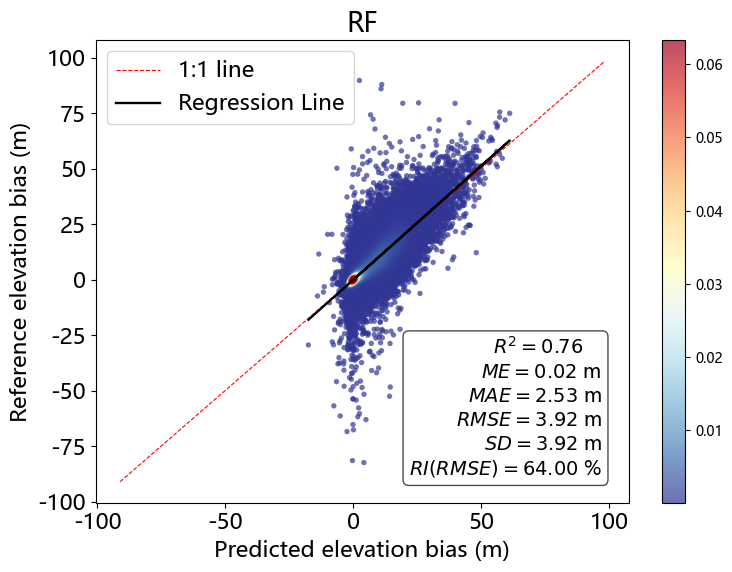

In [25]:
DrawFigure(pred_RF, test_labels_1d, title="RF", imp=64, sample_frac=0.01, random_state=42)


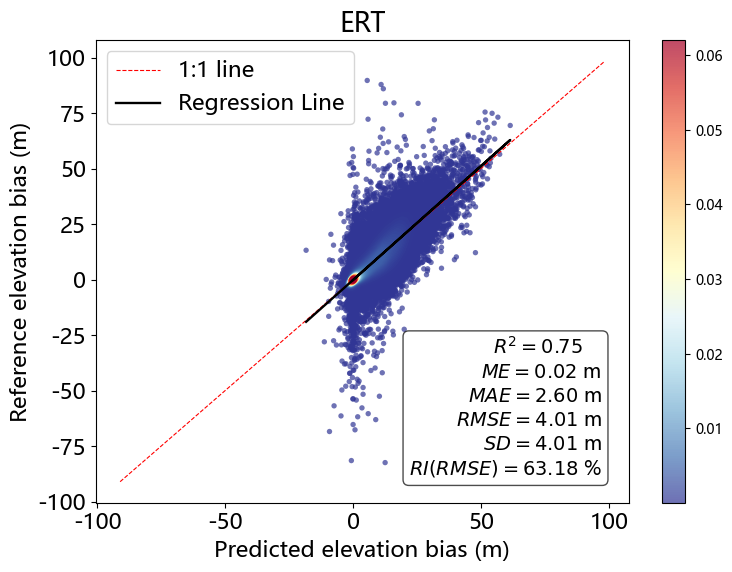

In [26]:
DrawFigure(pred_ETF, test_labels_1d, title="ERT", imp=63.18, sample_frac=0.01, random_state=42)


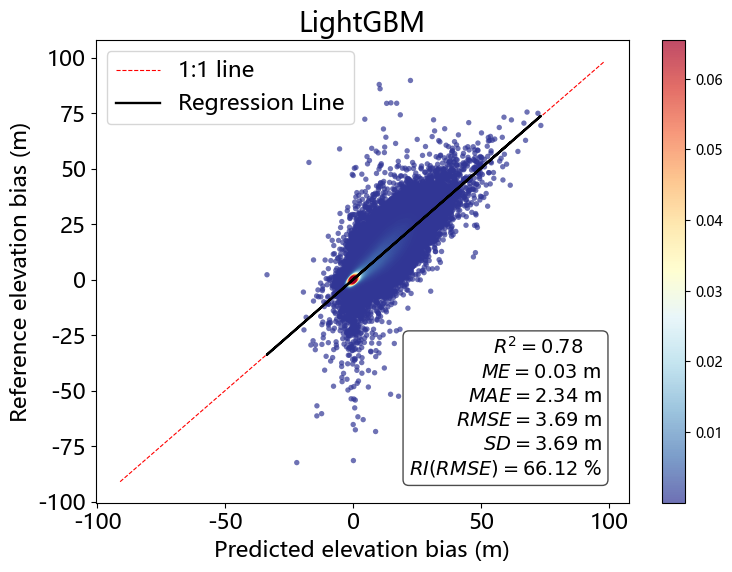

In [27]:
DrawFigure(pred_LightGBM, test_labels_1d, title="LightGBM", imp=66.12, sample_frac=0.01, random_state=42)


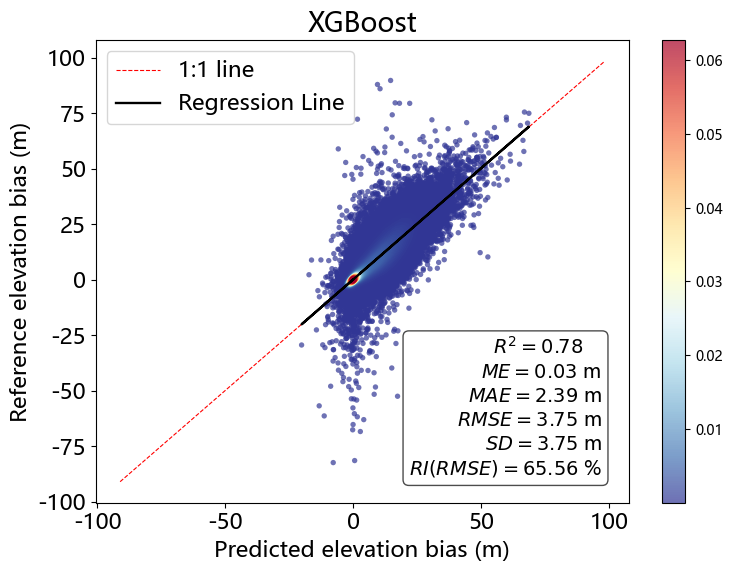

In [28]:
DrawFigure(pred_XGBoost, test_labels_1d, title="XGBoost", imp=65.56, sample_frac=0.01, random_state=42)


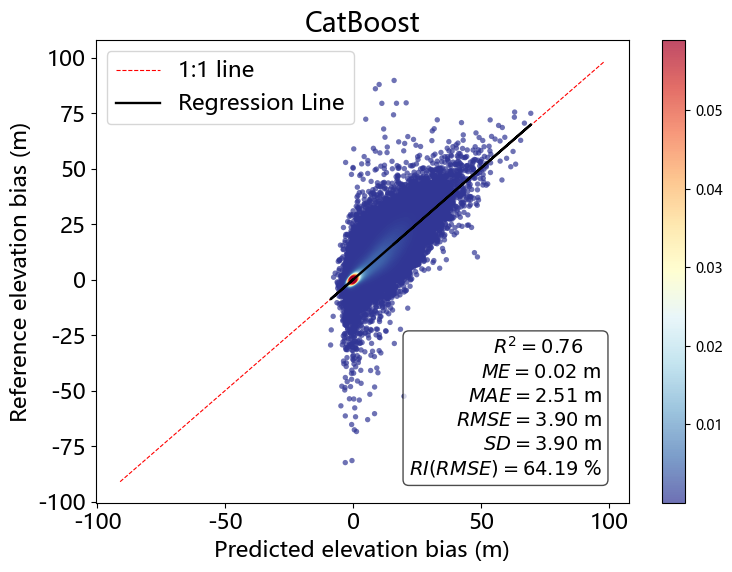

In [29]:
DrawFigure(pred_CatBoost, test_labels_1d, title="CatBoost", imp=64.19, sample_frac=0.01, random_state=42)


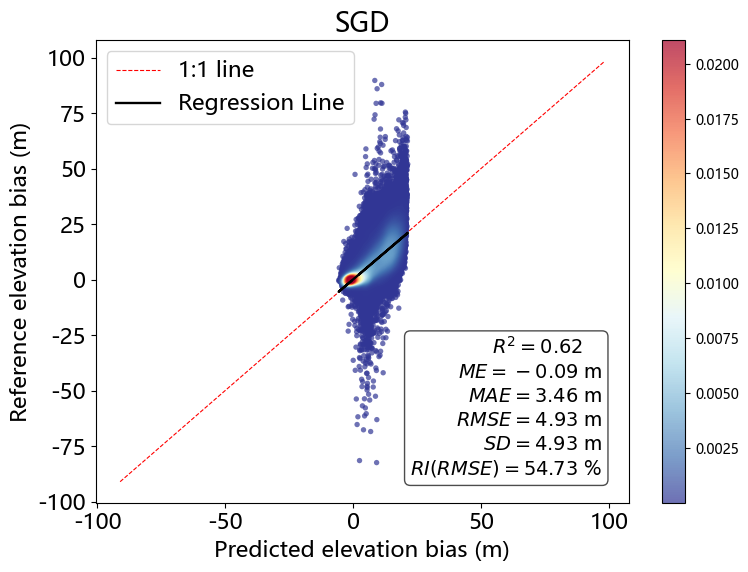

In [30]:
DrawFigure(pred_SGD, test_labels_1d, title="SGD", imp=54.73, sample_frac=0.01, random_state=42)


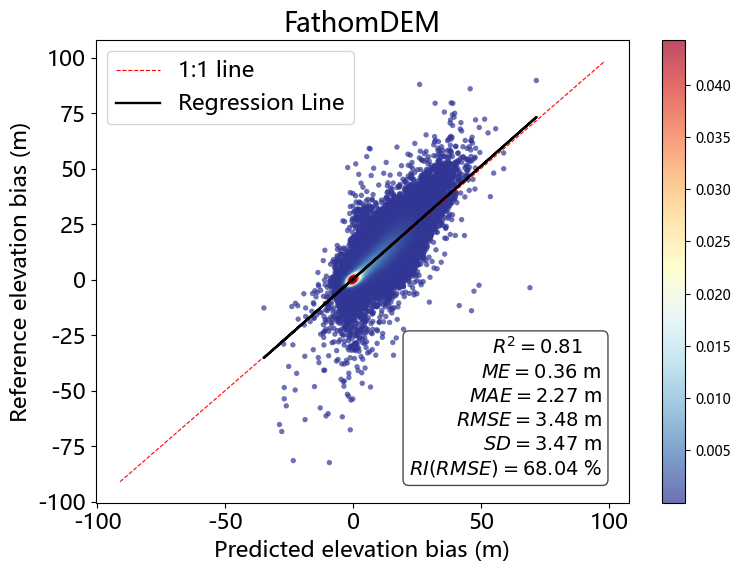

In [31]:
DrawFigure(pred_Fathom, test_labels_1d, title="FathomDEM", imp=68.04, sample_frac=0.01, random_state=42)


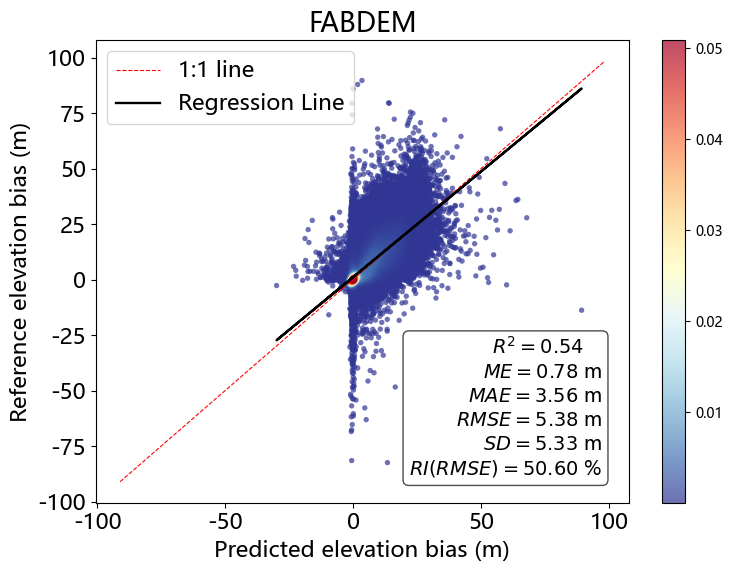

In [32]:
DrawFigure(pred_FABDEM, test_labels_1d, title="FABDEM", imp=50.60, sample_frac=0.01, random_state=42)


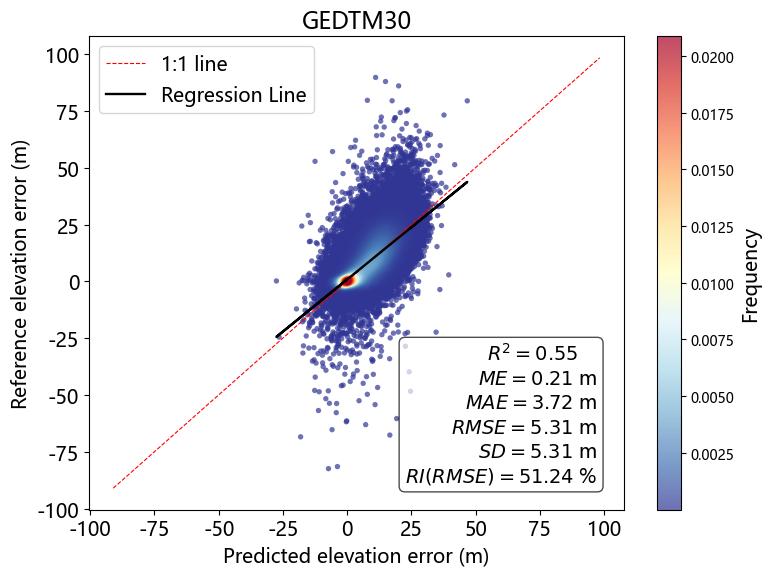

In [12]:
DrawFigure(pred_GEDTM30, test_labels_1d, title="GEDTM30", imp=51.24, sample_frac=0.01, random_state=42)


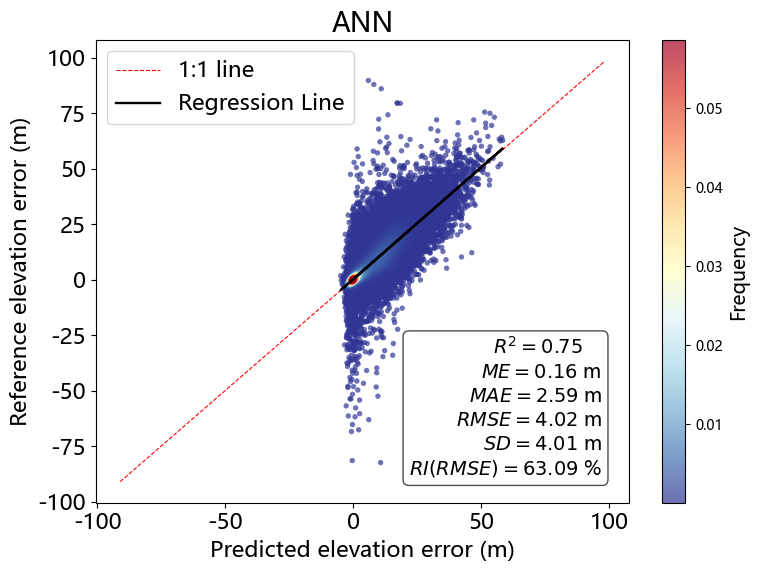

In [18]:
DrawFigure(pred_ANN, test_labels_1d, title="ANN", imp=63.09, sample_frac=0.01, random_state=42)


# HRDEMs

In [ ]:
"""
The data volume is too large to upload. Please refer to the run history.
"""

### Section 4.2.2

In [9]:
cols_names = [
    "Pid","IDW", "FABDEM", "GEDTM30", "FathomDEM", "HRDEM", "Lon", "Lat","LandCover", "LandForm",
    "ForestCoverage", "ForestHeight", "ForestHeight10", "ForestHeight30",
    "BuildingHeight90", "Pop", "NightLight",
    "Aspect", "Hillshade", "Curvature", "ProfileCur", "PlanCur", 
    "DEM", "STDDEM", "Max_MinDEM", "Mean_MinDEM", "deltMeanDEM", "deltMedianDEM", "deltMinDEM", "deltMaxDEM",
    "Slope", "MaxSlope", "STDSlope", "Mean_MinSlope", "Max_MinSlope", "deltMeanSlope", "SOS", "SOA","HEL","FCLoss","FCGain","NIR","RGB","SAR_VV","SAR_VH"
]


Validation_list=["WestAmerica_10","WestAmerica_44","EastAmerica_5","France20","UK3",'NorthLand',"WestCoast_validation", 'almeria',  'canyon',  'ebro', 'la', 'trentino']

for area in  Validation_list:
    print(f"{area} is working....")

    numpy_Mountain = np.load(r"I:\DC_HR\NPZ_HRDEMs\FullAreas\Numpy_{}_64.npy".format(area)) 


    if area in ["WestAmerica_10","WestAmerica_44","EastAmerica_5"]:
        Folder="America"
    elif area in ["France20","UK3"]:
        Folder="European"
    elif area in ['NorthLand','WestCoast_validation']:
        Folder="NewZeeland"
    else:
        Folder="DEMIX"

    genTrainingData_HRDEM(numpy_Mountain,cols_names, selected_features,mean_std_path, IsEmpty=False) # All Areas

    B, C, H, W = test_data.shape
    test_data_2d = test_data.transpose(0, 2, 3, 1).reshape(-1, C)  # (B*H*W, C)
    test_labels_1d = test_labels.reshape(-1)  # (B*H*W,)

    test_DEM_1d = test_DEM.reshape(-1)  # (B*H*W,)

    fathom_rmse = np.sqrt(mean_squared_error(test_labels_1d,test_DEM_1d- test_FathomDEM.reshape(-1)))
    fab_rmse = np.sqrt(mean_squared_error(test_labels_1d, test_DEM_1d- test_FABDEM.reshape(-1)))
    gedtm30_rmse = np.sqrt(mean_squared_error(test_labels_1d, test_DEM_1d- test_GEDTM30.reshape(-1)))
    raw_rmse = np.sqrt(mean_squared_error(test_labels_1d, np.zeros_like(test_labels_1d)))
    
    print(f"Cop RMSE:{raw_rmse:0.2f}   Fathom:{fathom_rmse:0.2f}   FABDEM:{fab_rmse:0.2f}   GEDTM30:{gedtm30_rmse:0.2f} \n \n")
    

    for label in ["RF","ERT","LightGBM","XGBoost","CatBoost","ANN","SGD"]:

        print(f"......{label}.........")
        if label=="ANN":
            predError_1d=predML_Models(test_data_2d,test_labels_1d,modelPath=r"I:\DC_HR\Models_MR\STD_CNNSHAP15\ComparisonModels\ANN_All.pth".format(label))
        else:
            predError_1d=predML_Models(test_data_2d,test_labels_1d,modelPath=r"I:\DC_HR\Models_MR\STD_CNNSHAP15\ComparisonModels\{}_All.pkl".format(label))
        
    print()
    


WestAmerica_10 is working....
Cop RMSE:14.43   Fathom:4.01   FABDEM:6.48   GEDTM30:5.62 
 

......RF.........
----- RMSE--- Elevation:4.26   Slope:2.85   Curvature:0.0281 

......ERT.........
----- RMSE--- Elevation:4.34   Slope:2.89   Curvature:0.0278 

......LightGBM.........
----- RMSE--- Elevation:4.17   Slope:2.82   Curvature:0.0273 

......XGBoost.........
----- RMSE--- Elevation:4.22   Slope:2.85   Curvature:0.0274 

......CatBoost.........
----- RMSE--- Elevation:4.25   Slope:2.87   Curvature:0.0290 

......ANN.........
----- RMSE--- Elevation:4.40   Slope:2.94   Curvature:0.0293 

......SGD.........
----- RMSE--- Elevation:5.25   Slope:3.23   Curvature:0.0324 


WestAmerica_44 is working....
Cop RMSE:11.10   Fathom:2.96   FABDEM:5.42   GEDTM30:4.78 
 

......RF.........
----- RMSE--- Elevation:3.83   Slope:2.29   Curvature:0.0228 

......ERT.........
----- RMSE--- Elevation:3.80   Slope:2.34   Curvature:0.0228 

......LightGBM.........
----- RMSE--- Elevation:3.65   Slope:2.21

## Flow Accuracy validation

In [2]:
import json
import arcpy
from arcpy.sa import *
import numpy as np
import os
import pandas as pd
from osgeo import osr
from osgeo import gdal
import glob

import arcpy
import numpy as np

def flowDirSim(ref_flowdir, cmp_flowdir):
    ref = arcpy.RasterToNumPyArray(ref_flowdir, nodata_to_value=-9999)
    cmp = arcpy.RasterToNumPyArray(cmp_flowdir, nodata_to_value=-9999)


    mask = (ref != -9999)

    total = np.sum(mask)  
    same = np.sum((ref == cmp) & mask)  

    if total == 0:
        return None
    return round(100*same / total,2)



def calD8(inputDEM):
    inputDEM=arcpy.Raster(inputDEM)

    FilledDEM = arcpy.sa.Fill(
        in_surface_raster=inputDEM,
        z_limit=None
    )

    flowDir = arcpy.sa.FlowDirection(
        in_surface_raster=FilledDEM,
        force_flow="NORMAL",
        out_drop_raster=None,
        flow_direction_type="D8"
    )

    return flowDir

arcpy.env.workspace=r"D:\AAA_Working\tempdata"

Area_list=["WestAmerica_10","WestAmerica_44","EastAmerica_5","France20","UK3",'NorthLand','WestCoast_validation','almeria',  'canyon',  'ebro', 'la', 'trentino']

baseFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\MLCorrectedResults\CorrectedDEM_MR_AllAreas"


for area in Area_list:
    
    arcpy.env.extent =None

    print(f"-------------{area}---------------")

    if area in ["WestAmerica_10","WestAmerica_44","EastAmerica_5"]:
        Folder="America"
    elif area in ["France20","UK3"]:
        Folder="European"
    elif area in ['NorthLand','WestCoast_validation']:
        Folder="NewZeeland"
    else:
        Folder="DEMIX"

    if area != 'WestCoast_validation':
        refDEM=arcpy.Raster(os.path.join(r"D:\AAA_Working\DC_HR_Dataset\{}\HRDEMs".format(Folder),f"{area}.tif"))
        CopDEM=arcpy.Raster(os.path.join(r"D:\AAA_Working\DC_HR_Dataset\{}\CopDEM".format(Folder),f"Cop_WGS84_{area}.tif"))
        FABDEM=arcpy.Raster(os.path.join(r"D:\AAA_Working\DC_HR_Dataset\{}\FABDEM".format(Folder),f"FAB_WGS84_{area}.tif"))
        Fathom=arcpy.Raster(os.path.join(r"D:\AAA_Working\DC_HR_Dataset\{}\FathomDEM".format(Folder),f"Fathom_{area}.tif"))*0.01
        GEDTM30=arcpy.Raster(os.path.join(r"D:\AAA_Working\DC_HR_Dataset\{}\GEDTM30".format(Folder),f"GEDTM30_{area}.tif"))
    else:
        refDEM=arcpy.Raster(os.path.join(r"D:\AAA_Working\DC_HR_Dataset\{}\HRDEMs".format(Folder),f"WestCoast.tif"))
        CopDEM=arcpy.Raster(os.path.join(r"D:\AAA_Working\DC_HR_Dataset\{}\CopDEM".format(Folder),f"Cop_WGS84_WestCoast.tif"))
        FABDEM=arcpy.Raster(os.path.join(r"D:\AAA_Working\DC_HR_Dataset\{}\FABDEM".format(Folder),f"FAB_WGS84_WestCoast.tif"))
        Fathom=arcpy.Raster(os.path.join(r"D:\AAA_Working\DC_HR_Dataset\{}\FathomDEM".format(Folder),f"Fathom_WestCoast.tif"))*0.01
        GEDTM30=arcpy.Raster(os.path.join(r"D:\AAA_Working\DC_HR_Dataset\{}\GEDTM30".format(Folder),f"GEDTM30_WestCoast.tif"))

    CTSE=calD8(inputDEM=os.path.join(baseFolder,f"{area}_Proposed_AllAreas.tif"))
    SnapArea= Con(~IsNull(CTSE), 1) 
    arcpy.env.extent = SnapArea.extent  
  
    refDEM= calD8(inputDEM=refDEM) * SnapArea
    CopDEM= calD8(inputDEM=CopDEM) * SnapArea
    FABDEM= calD8(inputDEM=FABDEM) * SnapArea
    Fathom= calD8(inputDEM=Fathom) * SnapArea
    GEDTM30= calD8(inputDEM=GEDTM30) * SnapArea

    CNN= calD8(inputDEM=os.path.join(baseFolder,f"{area}_CNN_AllAreas.tif")) * SnapArea
    RF= calD8(inputDEM=os.path.join(baseFolder,f"{area}_RF_AllAreas.tif")) * SnapArea
    ERT= calD8(inputDEM=os.path.join(baseFolder,f"{area}_ERT_AllAreas.tif")) * SnapArea
    CatBoost= calD8(inputDEM=os.path.join(baseFolder,f"{area}_CatBoost_AllAreas.tif")) * SnapArea
    XGBoost= calD8(inputDEM=os.path.join(baseFolder,f"{area}_XGBoost_AllAreas.tif")) * SnapArea
    LightGBM= calD8(inputDEM=os.path.join(baseFolder,f"{area}_LightGBM_AllAreas.tif")) * SnapArea
    ANN= calD8(inputDEM=os.path.join(baseFolder,f"{area}_ANN_AllAreas.tif")) * SnapArea
    SGD= calD8(inputDEM=os.path.join(baseFolder,f"{area}_SGD_AllAreas.tif")) * SnapArea


    print(f" CopDEM: {flowDirSim(refDEM, CopDEM)}     CTSE: {flowDirSim(refDEM, CTSE)}   CNN: {flowDirSim(refDEM, CNN)}   RF: {flowDirSim(refDEM, RF)}    ERT: {flowDirSim(refDEM, ERT)}    LightGBM: {flowDirSim(refDEM, LightGBM)}  \
           XGBoost: {flowDirSim(refDEM, XGBoost)}   CatBoost: {flowDirSim(refDEM, CatBoost)}   NN: {flowDirSim(refDEM, ANN)}   SGD: {flowDirSim(refDEM, SGD)}   Fathom: {flowDirSim(refDEM, Fathom)}   FAB: {flowDirSim(refDEM, FABDEM)}    GEDTM30: {flowDirSim(refDEM, GEDTM30)}   ")
    

    
    print()





-------------WestAmerica_10---------------
 CopDEM: 66.32     CTSE: 79.03   CNN: 76.99   RF: 70.73    ERT: 70.15    LightGBM: 70.35             XGBoost: 69.8   CatBoost: 70.44   NN: 69.82   SGD: 68.41   Fathom: 72.83   FAB: 63.31    GEDTM30: 64.02   

-------------WestAmerica_44---------------
 CopDEM: 61.36     CTSE: 72.16   CNN: 70.93   RF: 62.42    ERT: 60.67    LightGBM: 63.01             XGBoost: 60.75   CatBoost: 62.28   NN: 62.1   SGD: 59.18   Fathom: 71.37   FAB: 60.59    GEDTM30: 57.91   

-------------EastAmerica_5---------------
 CopDEM: 62.61     CTSE: 78.98   CNN: 76.83   RF: 63.78    ERT: 63.42    LightGBM: 63.63             XGBoost: 63.25   CatBoost: 63.79   NN: 63.83   SGD: 62.65   Fathom: 73.48   FAB: 59.25    GEDTM30: 58.73   

-------------France20---------------
 CopDEM: 79.16     CTSE: 86.03   CNN: 84.51   RF: 80.53    ERT: 79.92    LightGBM: 81.54             XGBoost: 80.88   CatBoost: 81.16   NN: 80.89   SGD: 76.63   Fathom: 84.49   FAB: 77.64    GEDTM30: 74.52  

# ICESat-Areas

In [ ]:
"""
The data volume is too large to upload. Please refer to the run history.
"""

In [2]:
import json
import arcpy
from arcpy.sa import *
import numpy as np
import os
import pandas as pd
from osgeo import osr
from osgeo import gdal
import glob
from scipy.stats import t
RFDEM=ETFDEM=XGBDEM=CatDEM=LightDEM=NLDEM=CNNDEM=FABDEM=CopDEM=FathomDEM=GEDTM30=ANNDEM=CTSEDEM=SGDDEM=None

def filterPandas(df):
    
    df['DEM_ATL'] = df['CopDEM'] - df['EGM2008'] 
    mean_value = df['DEM_ATL'].mean()
    std_value = df['DEM_ATL'].std()
    lower_bound = mean_value - 3 * std_value
    upper_bound = mean_value + 3 * std_value
    filtered_df = df[(df['DEM_ATL'] >= lower_bound) & (df['DEM_ATL'] <= upper_bound)]
    filtered_df = filtered_df.reset_index(drop=True)
    return filtered_df


def run(ATL08Points):
    global RFDEM, ETFDEM, XGBDEM, CatDEM, LightDEM, NLDEM, CNNDEM, FABDEM, CopDEM, FathomDEM, GEDTM30, CTSEDEM,ANNDEM,SGDDEM

    raster_mappings = [
        (RFDEM, "RFDEM"),
        (ETFDEM, "ETFDEM"),
        (XGBDEM, "XGBDEM"),
        (CatDEM, "CatDEM"),
        (LightDEM, "LightDEM"),
        (SGDDEM, "SGDDEM"),
        (CNNDEM, "CNNDEM"),
        (FABDEM, "FABDEM"),
        (ANNDEM, "ANNDEM"),
        (CopDEM, "CopDEM"),
        (FathomDEM, "FathomDEM"),
        (GEDTM30, "GEDTM30"),
        (CTSEDEM, "CTSEDEM")  
]
   

    in_rasters_str = ";".join([f"{raster} {field}" for raster, field in raster_mappings])


    fields_to_add = [field for _, field in raster_mappings]
    existing_fields = [f.name for f in arcpy.ListFields(ATL08Points)]
    fields_to_delete = [field for field in fields_to_add if field in existing_fields]

    if fields_to_delete:
        arcpy.DeleteField_management(ATL08Points, fields_to_delete)

    arcpy.sa.ExtractMultiValuesToPoints(
        in_point_features=ATL08Points,
        in_rasters=in_rasters_str,
        bilinear_interpolate_values="BILINEAR"
    )



    columns_to_check = ["CopDEM", "CTSEDEM",'FABDEM','FathomDEM','GEDTM30',"EGM2008"]  

    field_names = [field.name for field in arcpy.ListFields(ATL08Points) if field.type != 'Geometry']


    data = []
    with arcpy.da.SearchCursor(ATL08Points, field_names) as cursor:
        for row in cursor:
            data.append(row)
    df = pd.DataFrame(data, columns=field_names)

    df = df[(df[columns_to_check] > 0).all(axis=1)]

    df=filterPandas(df)

    df = df[~df["LandC"].isin( [187,210,0] )] 

    metrics = {}

    models = {
        "CopDEM": "CopDEM",
        "CTSEDEM": "CTSEDEM",
        "CNN": "CNNDEM",
        "FathomDEM": "FathomDEM",
        "FABDEM": "FABDEM",
        "GEDTM30": "GEDTM30",
        "RF": "RFDEM",
        "ETF": "ETFDEM",
        "XGB": "XGBDEM",
        "SGD":"SGDDEM",
        "Cat": "CatDEM",
        "LightGBM": "LightDEM",
        "ANN": "ANNDEM"
    }

    n = len(df)

    t_val = t.ppf(1 - 0.025, df=n - 1)

    for name, col in models.items():
        residuals = df['EGM2008'] - df[col]
        rmse = np.sqrt(np.mean(residuals ** 2))
        se = np.std(residuals, ddof=1) / np.sqrt(n)  
   
        metrics[name] = {"RMSE": rmse}


    rmse_str = " ".join([f"{name}: {metrics[name]['RMSE']:.2f}" for name in metrics])

    print(f"--RMSE-- {rmse_str}")






In [ ]:
"""
The data volume is too large to upload. Please refer to the run history.
"""

In [ ]:

Area_list=["ICESat_Area"+ str(id) for id in [1,2,3,4,5,6,7,8,9,10]]

sharedFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion"


MLResultFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\MLCorrectedResults\CorrectedDEM_MR_AllAreas" # AllAreas

ATL08Folder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\AFusion_Validation\TrainingATL08_v2"

for k, areaLabel in  enumerate(Area_list):
 
    print(f"IA {k+1} is working....")

    iceLabel=areaLabel.split("_")[-1]
    ATL08Points=os.path.join(ATL08Folder,f"ATL08Points_{iceLabel}_validation.shp")

    Cop_DEM=os.path.join(os.path.join(sharedFolder,"CopDEM"),f"Cop_WGS84_{areaLabel}.tif")
    CopDEM=arcpy.Raster(Cop_DEM)

    CTSEDEM=os.path.join(MLResultFolder,f"{areaLabel}_Proposed_AllAreas.tif")
    CTSEDEM=arcpy.Raster(CTSEDEM)

    FAB_DEM=os.path.join(os.path.join(sharedFolder,"FABDEM"),f"FAB_WGS84_{areaLabel}.tif")
    FABDEM=arcpy.Raster(FAB_DEM)

    Fathom_DEM=os.path.join(os.path.join(sharedFolder,"FathomDEM"),f"Fathom_{areaLabel}.tif")
    FathomDEM=arcpy.Raster(Fathom_DEM)*0.01

    GEDTM30_DEM=os.path.join(os.path.join(sharedFolder,"GEDTM30"),f"GEDTM30_{areaLabel}.tif")
    GEDTM30=arcpy.Raster(GEDTM30_DEM)

    RFDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_RF_AllAreas.tif"))
    ETFDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_ERT_AllAreas.tif"))
    LightDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_LightGBM_AllAreas.tif"))
    XGBDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_XGBoost_AllAreas.tif"))
    CatDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_CatBoost_AllAreas.tif"))
    ANNDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_ANN_AllAreas.tif"))
    SGDDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_SGD_AllAreas.tif"))
    
    CNNDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_CNN_AllAreas.tif"))
    
    run(ATL08Points)
    print()


        

IA 1 is working....
--RMSE-- CopDEM: 15.58 CTSEDEM: 8.59 CNN: 8.50 FathomDEM: 8.60 FABDEM: 9.10 GEDTM30: 9.23 RF: 8.50 ETF: 8.56 XGB: 8.49 SGD: 8.51 Cat: 8.45 LightGBM: 8.51 ANN: 8.57

IA 2 is working....
--RMSE-- CopDEM: 13.32 CTSEDEM: 8.52 CNN: 8.44 FathomDEM: 9.35 FABDEM: 9.53 GEDTM30: 9.58 RF: 8.43 ETF: 8.45 XGB: 8.61 SGD: 8.80 Cat: 8.63 LightGBM: 8.59 ANN: 8.66

IA 3 is working....
--RMSE-- CopDEM: 14.43 CTSEDEM: 8.81 CNN: 9.07 FathomDEM: 9.32 FABDEM: 10.26 GEDTM30: 10.06 RF: 9.24 ETF: 9.34 XGB: 9.29 SGD: 8.92 Cat: 9.34 LightGBM: 9.32 ANN: 9.39

IA 4 is working....
--RMSE-- CopDEM: 21.78 CTSEDEM: 9.39 CNN: 10.01 FathomDEM: 11.61 FABDEM: 10.33 GEDTM30: 10.64 RF: 9.75 ETF: 9.75 XGB: 9.44 SGD: 10.14 Cat: 9.91 LightGBM: 9.61 ANN: 10.85

IA 5 is working....
--RMSE-- CopDEM: 25.74 CTSEDEM: 13.22 CNN: 13.27 FathomDEM: 14.85 FABDEM: 14.09 GEDTM30: 15.15 RF: 13.81 ETF: 13.78 XGB: 14.03 SGD: 15.85 Cat: 13.90 LightGBM: 14.13 ANN: 14.43

IA 6 is working....
--RMSE-- CopDEM: 22.82 CTSEDEM: 10.

# GEDI

In [ ]:
"""
The data volume is too large to upload. Please refer to the run history.
"""

In [ ]:
import json
import arcpy
from arcpy.sa import *
import numpy as np
import os
import pandas as pd
from osgeo import osr
from osgeo import gdal
import glob
from scipy.stats import t
RFDEM=ETFDEM=XGBDEM=CatDEM=LightDEM=NLDEM=CNNDEM=FABDEM=CopDEM=FathomDEM=GEDTM30=ANNDEM=CTSEDEM=SGDDEM=None

def filterPandas(df):
    
    df['DEM_ATL'] = df['CopDEM'] - df['EGM2008'] 
    mean_value = df['DEM_ATL'].mean()
    std_value = df['DEM_ATL'].std()
    lower_bound = mean_value - 3 * std_value
    upper_bound = mean_value + 3 * std_value
    filtered_df = df[(df['DEM_ATL'] >= lower_bound) & (df['DEM_ATL'] <= upper_bound)]
    filtered_df = filtered_df.reset_index(drop=True)
    return filtered_df


def run(ATL08Points):
    global RFDEM, ETFDEM, XGBDEM, CatDEM, LightDEM, NLDEM, CNNDEM, FABDEM, CopDEM, FathomDEM, GEDTM30, CTSEDEM,ANNDEM,SGDDEM

    raster_mappings = [
        (RFDEM, "RFDEM"),
        (ETFDEM, "ETFDEM"),
        (XGBDEM, "XGBDEM"),
        (CatDEM, "CatDEM"),
        (LightDEM, "LightDEM"),
        (SGDDEM, "SGDDEM"),
        (CNNDEM, "CNNDEM"),
        (FABDEM, "FABDEM"),
        (ANNDEM, "ANNDEM"),
        (CopDEM, "CopDEM"),
        (FathomDEM, "FathomDEM"),
        (GEDTM30, "GEDTM30"),
        (CTSEDEM, "CTSEDEM")  
]
   

    in_rasters_str = ";".join([f"{raster} {field}" for raster, field in raster_mappings])


    fields_to_add = [field for _, field in raster_mappings]
    existing_fields = [f.name for f in arcpy.ListFields(ATL08Points)]
    fields_to_delete = [field for field in fields_to_add if field in existing_fields]

    if fields_to_delete:
        arcpy.DeleteField_management(ATL08Points, fields_to_delete)

    arcpy.sa.ExtractMultiValuesToPoints(
        in_point_features=ATL08Points,
        in_rasters=in_rasters_str,
        bilinear_interpolate_values="BILINEAR"
    )

   
    columns_to_check = ["CopDEM", "CTSEDEM",'FABDEM','FathomDEM','GEDTM30']  

    field_names = [field.name for field in arcpy.ListFields(ATL08Points) if field.type != 'Geometry']


    data = []
    with arcpy.da.SearchCursor(ATL08Points, field_names) as cursor:
        for row in cursor:
            data.append(row)
    df = pd.DataFrame(data, columns=field_names)

    df = df[(df[columns_to_check] > 0).all(axis=1)]

    df=filterPandas(df)
    df = df[~df["LandC"].isin( [187,210,0] )] 


 
    metrics = {}

    models = {
        "CopDEM": "CopDEM",
        "CTSEDEM": "CTSEDEM",
        "CNN": "CNNDEM",
        "RF": "RFDEM",
        "ETF": "ETFDEM",
        "LightGBM": "LightDEM",
        "XGB": "XGBDEM",
        "Cat": "CatDEM",
        "ANN": "ANNDEM",
        "SGD":"SGDDEM",
        "FathomDEM": "FathomDEM",
        "FABDEM": "FABDEM",
        "GEDTM30": "GEDTM30"
    }

    n = len(df)

    t_val = t.ppf(1 - 0.025, df=n - 1)

    for name, col in models.items():
        residuals = df['EGM2008'] - df[col]
        rmse = np.sqrt(np.mean(residuals ** 2))
        se = np.std(residuals, ddof=1) / np.sqrt(n)  
        ci_radius = t_val * se 
        metrics[name] = {"RMSE": rmse, "ErrBar": ci_radius}

    
    rmse_str = " ".join([f"{name}: {metrics[name]['RMSE']:.2f}" for name in metrics])
    err_str = " ".join([f"{name}: {metrics[name]['ErrBar']:.2f}" for name in metrics])

    print(f"--RMSE-- {rmse_str}")


        

In [ ]:
Area_list=["ICESat_Area"+ str(id) for id in [1,2,3,4,5,6,7,8,9,10]]

Id_list= [1,2,3,4,5,6,7,8,9,10]

sharedFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion"
MLResultFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\MLCorrectedResults\CorrectedDEM_MR_AllAreas"
ATL08Folder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\AFusion_Validation\GEDI"

k=0
for k,areaLabel in  enumerate(Area_list):

    print(f"IA {k+1} is working....")
    iceLabel=areaLabel.split("_")[-1]
    
    id=Id_list[k]
    ATL08Points=os.path.join(ATL08Folder,f"GEDI_{areaLabel}_Distance30.shp")
    k+=1

    Cop_DEM=os.path.join(os.path.join(sharedFolder,"CopDEM"),f"Cop_WGS84_{areaLabel}.tif")
    CopDEM=arcpy.Raster(Cop_DEM)

    CTSEDEM=os.path.join(MLResultFolder,f"{areaLabel}_Proposed_AllAreas.tif")
    CTSEDEM=arcpy.Raster(CTSEDEM)

    FAB_DEM=os.path.join(os.path.join(sharedFolder,"FABDEM"),f"FAB_WGS84_{areaLabel}.tif")
    FABDEM=arcpy.Raster(FAB_DEM)

    Fathom_DEM=os.path.join(os.path.join(sharedFolder,"FathomDEM"),f"Fathom_{areaLabel}.tif")
    FathomDEM=arcpy.Raster(Fathom_DEM)*0.01

    GEDTM30_DEM=os.path.join(os.path.join(sharedFolder,"GEDTM30"),f"GEDTM30_{areaLabel}.tif")
    GEDTM30=arcpy.Raster(GEDTM30_DEM)

    RFDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_RF_AllAreas.tif"))
    ETFDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_ERT_AllAreas.tif"))
    LightDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_LightGBM_AllAreas.tif"))
    XGBDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_XGBoost_AllAreas.tif"))
    CatDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_CatBoost_AllAreas.tif"))
    ANNDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_ANN_AllAreas.tif"))
    SGDDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_SGD_AllAreas.tif"))

    CNNDEM=arcpy.Raster(os.path.join(MLResultFolder,f"{areaLabel}_CNN_AllAreas.tif"))
    
    run(ATL08Points)
    print()

        

IA 1 is working....
--RMSE-- CopDEM: 17.90 CTSEDEM: 10.41 CNN: 10.37 RF: 10.39 ETF: 10.39 LightGBM: 10.58 XGB: 10.57 Cat: 10.49 ANN: 10.55 SGD: 10.63 FathomDEM: 10.76 FABDEM: 11.17 GEDTM30: 11.62

IA 2 is working....
--RMSE-- CopDEM: 15.98 CTSEDEM: 10.77 CNN: 10.70 RF: 10.94 ETF: 10.90 LightGBM: 11.18 XGB: 11.19 Cat: 11.15 ANN: 11.15 SGD: 10.96 FathomDEM: 11.64 FABDEM: 12.05 GEDTM30: 12.19

IA 3 is working....
--RMSE-- CopDEM: 16.56 CTSEDEM: 10.36 CNN: 10.70 RF: 11.22 ETF: 11.26 LightGBM: 11.29 XGB: 11.30 Cat: 11.28 ANN: 11.29 SGD: 11.38 FathomDEM: 11.20 FABDEM: 12.10 GEDTM30: 12.18

IA 4 is working....
--RMSE-- CopDEM: 23.46 CTSEDEM: 11.16 CNN: 11.70 RF: 11.84 ETF: 11.78 LightGBM: 11.48 XGB: 11.48 Cat: 11.86 ANN: 12.54 SGD: 12.50 FathomDEM: 13.32 FABDEM: 12.37 GEDTM30: 13.03

IA 5 is working....
--RMSE-- CopDEM: 26.70 CTSEDEM: 15.62 CNN: 16.10 RF: 17.16 ETF: 17.17 LightGBM: 17.26 XGB: 17.21 Cat: 17.20 ANN: 17.71 SGD: 18.53 FathomDEM: 17.04 FABDEM: 17.47 GEDTM30: 18.20

IA 6 is working

# AW3D30 comparison

In [ ]:
"""
The data volume is too large to upload. Please refer to the run history.
"""

## HRDEMs

In [ ]:
import arcpy
from arcpy.sa import *
import os
import numpy as np
from osgeo import gdal
arcpy.env.overwriteOutput=True

import numpy as np
import arcpy

def calRMSE(CortDEM, HRDEM, trim_ratio=0.05):
  

    DifEle_DC = CortDEM - HRDEM

    squared_diff = arcpy.sa.Square(DifEle_DC)
 
    sq_arr = arcpy.RasterToNumPyArray(squared_diff, nodata_to_value=np.nan).astype("float64")

    sq_arr = sq_arr.ravel()
    sq_arr = sq_arr[np.isfinite(sq_arr)]

    sorted_sq = np.sort(sq_arr)

    n = sorted_sq.size
    low = int(n * trim_ratio)         
    high = int(n * (1 - trim_ratio)) 


    trimmed_sq = sorted_sq[low:high]

 
    rmse = np.sqrt(np.mean(trimmed_sq))

    return rmse

In [ ]:


DEM_Folder=r"D:\AAA_Working\DC_HR_Dataset\AW3D30\CopDEM_REf"
CortnoSm_Folder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\MLCorrectedResults\HRAreas"
AW3D30_Folder=r"D:\AAA_Working\DC_HR_Dataset\AW3D30\AW3D30_EGM2008"

Area_list=["WestAmerica_10","WestAmerica_44","EastAmerica_5","France20","UK3",'NorthLand','WestCoast_validation','almeria',  'canyon',  'ebro', 'la', 'trentino']


for area in Area_list:

    if area in ["WestAmerica_10","WestAmerica_44","EastAmerica_5"]:
        Folder="America"
    elif area in ["France20","UK3"]:
        Folder="European"
    elif area in ['NorthLand','WestCoast_validation']:
        Folder="NewZeeland"
    else:
        Folder="DEMIX"



    HRDEM_Folder=r"D:\AAA_Working\DC_HR_Dataset\{}\HRDEMs".format(Folder)
    FAB_Folder=r"D:\AAA_Working\DC_HR_Dataset\{}\FABDEM".format(Folder)
    Fathom_Folder=r"D:\AAA_Working\DC_HR_Dataset\{}\FathomDEM".format(Folder)
    GEDTM_Folder=r"D:\AAA_Working\DC_HR_Dataset\{}\GEDTM30".format(Folder)

    SnapDEM=arcpy.Raster(os.path.join(CortnoSm_Folder,f"{area}_CTSE.tif"))
    SnapArea= Con(~IsNull(SnapDEM), 1) 
    
    print(f"{area}..........")
    
    HRDEM=arcpy.Raster(os.path.join(HRDEM_Folder,f"{area}.tif"))
    DEM=arcpy.Raster(os.path.join(DEM_Folder,f"Cop_WGS84_{area}.tif"))

    FABDEM=arcpy.Raster(os.path.join(FAB_Folder,f"FAB_WGS84_{area}.tif"))
    Fathom=arcpy.Raster(os.path.join(Fathom_Folder,f"Fathom_{area}.tif"))*0.01
    GEDTM30=arcpy.Raster(os.path.join(GEDTM_Folder,f"GEDTM30_{area}.tif"))*0.1
    AW3D30=arcpy.Raster(os.path.join(AW3D30_Folder,f"AW3D30_{area}_EGM2008.tif"))

    HRDEM=HRDEM*SnapArea


    SnapDEM_Ele=calRMSE(SnapDEM,HRDEM)


    DEM=DEM*SnapArea
    Raw_Ele=calRMSE(DEM,HRDEM)

    FABDEM=FABDEM*SnapArea
    FAB_Ele=calRMSE(FABDEM,HRDEM)

    Fathom=Fathom*SnapArea
    Fathom_Ele=calRMSE(Fathom,HRDEM)

    GEDTM30=GEDTM30*SnapArea
    GEDTM30_Ele=calRMSE(GEDTM30,HRDEM)

    AW3D30=AW3D30*SnapArea
    AW3D30_Ele=calRMSE(AW3D30,HRDEM)

    # 依次输出
    print(f"-- RawDEM--  {Raw_Ele:0.2f} -- AW3D30-- {AW3D30_Ele:0.2f}  -- Proposed-- {SnapDEM_Ele:0.2f}    -- Fathom-- {Fathom_Ele:0.2f}   -- FABDEM  --  {FAB_Ele:0.2f}  -- GEDTM30 --  {GEDTM30_Ele:0.2f}  ")


   

WestAmerica_10..........
-- RawDEM--  12.92 -- AW3D30-- 12.59  -- Proposed-- 2.56    -- Fathom-- 3.22   -- FABDEM  --  5.31  -- GEDTM30 --  7.31  
WestAmerica_44..........
-- RawDEM--  11.26 -- AW3D30-- 12.34  -- Proposed-- 1.92    -- Fathom-- 2.61   -- FABDEM  --  5.03  -- GEDTM30 --  6.41  
EastAmerica_5..........
-- RawDEM--  12.49 -- AW3D30-- 11.71  -- Proposed-- 2.63    -- Fathom-- 2.94   -- FABDEM  --  5.12  -- GEDTM30 --  6.48  
France20..........
-- RawDEM--  4.96 -- AW3D30-- 6.05  -- Proposed-- 2.72    -- Fathom-- 2.72   -- FABDEM  --  3.34  -- GEDTM30 --  5.17  
UK3..........
-- RawDEM--  1.05 -- AW3D30-- 3.86  -- Proposed-- 0.59    -- Fathom-- 1.03   -- FABDEM  --  1.49  -- GEDTM30 --  2.98  
NorthLand..........
-- RawDEM--  10.42 -- AW3D30-- 12.94  -- Proposed-- 2.27    -- Fathom-- 3.60   -- FABDEM  --  4.63  -- GEDTM30 --  5.87  
WestCoast_validation..........
-- RawDEM--  13.28 -- AW3D30-- 14.76  -- Proposed-- 3.66    -- Fathom-- 4.34   -- FABDEM  --  5.37  -- GEDTM30 -- 

## ICESat-2 Areas

In [ ]:
import json
import arcpy
from arcpy.sa import *
import numpy as np
import os
import pandas as pd
from osgeo import osr
from osgeo import gdal
import glob
from scipy.stats import t
RFDEM=ETFDEM=XGBDEM=CatDEM=LightDEM=NLDEM=CNNDEM=FABDEM=CopDEM=FathomDEM=GEDTM30=ANNDEM=CTSEDEM=SGDDEM=None

def filterPandas(df):
    
    df['DEM_ATL'] = df['CopDEM'] - df['EGM2008'] 
    mean_value = df['DEM_ATL'].mean()
    std_value = df['DEM_ATL'].std()
    lower_bound = mean_value - 3 * std_value
    upper_bound = mean_value + 3 * std_value
    filtered_df = df[(df['DEM_ATL'] >= lower_bound) & (df['DEM_ATL'] <= upper_bound)]
    filtered_df = filtered_df.reset_index(drop=True)
    return filtered_df


def run(ATL08Points):
    global ALOSDEM, FABDEM, CopDEM, FathomDEM, GEDTM30, CTSEDEM

    raster_mappings = [
        (ALOSDEM, "ALOSDEM"),
        (CopDEM, "CopDEM"),
        (FathomDEM, "FathomDEM"),
        (GEDTM30, "GEDTM30"),
        (FABDEM, "FABDEM"),
]
   
  
    in_rasters_str = ";".join([f"{raster} {field}" for raster, field in raster_mappings])


    fields_to_add = [field for _, field in raster_mappings]
    existing_fields = [f.name for f in arcpy.ListFields(ATL08Points)]
    fields_to_delete = [field for field in fields_to_add if field in existing_fields]

    if fields_to_delete:
        arcpy.DeleteField_management(ATL08Points, fields_to_delete)

    arcpy.sa.ExtractMultiValuesToPoints(
        in_point_features=ATL08Points,
        in_rasters=in_rasters_str,
        bilinear_interpolate_values="BILINEAR"
    )


    columns_to_check = ["CopDEM", 'FABDEM','FathomDEM','GEDTM30','ALOSDEM']  

    field_names = [field.name for field in arcpy.ListFields(ATL08Points) if field.type != 'Geometry']

 
    data = []
    with arcpy.da.SearchCursor(ATL08Points, field_names) as cursor:
        for row in cursor:
            data.append(row)
    df = pd.DataFrame(data, columns=field_names)

    df = df[(df[columns_to_check] > 0).all(axis=1)]

    df=filterPandas(df)

    df['GEDTM30']=df['GEDTM30']*10


    metrics = {}

    models = {
        "CopDEM": "CopDEM",
        "ALOSDEM": "ALOSDEM",
        "FathomDEM": "FathomDEM",
        "FABDEM": "FABDEM",
        "GEDTM30": "GEDTM30",
 
    }

    n = len(df)


    trim_ratio = 0.05 

    for name, col in models.items():

        residuals = df['EGM2008'] - df[col]
        sq_err = (residuals ** 2).to_numpy()
        sq_err = sq_err[np.isfinite(sq_err)]
        sq_sorted = np.sort(sq_err)

        n = len(sq_sorted)
        low = int(n * trim_ratio)
        high = int(n * (1 - trim_ratio))

      
        sq_trim = sq_sorted[low:high]

      
        rmse = np.sqrt(np.mean(sq_trim))
        metrics[name] = {"RMSE": rmse}


       
        rmse_str = " ".join([f"{name}: {metrics[name]['RMSE']:.2f}" for name in metrics])
    
    print(f"--RMSE-- {rmse_str}")


Area_list=["ICESat_Area"+ str(id) for id in [1,2,3,4,5,6,7,8,9,10]]


sharedFolder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion"
ATL08Folder=r"D:\AAA_Working\DC_HR_Dataset\DEM_Fusion\AFusion_Validation\TrainingATL08_v2"
AW3D30_Folder=r"D:\AAA_Working\DC_HR_Dataset\AW3D30\AW3D30_EGM2008"


for k, areaLabel in  enumerate(Area_list):
 
    print(f"IA {k+1} is working....")

    iceLabel=areaLabel.split("_")[-1]
    ATL08Points=os.path.join(ATL08Folder,f"ATL08Points_{iceLabel}_validation.shp")

    Cop_DEM=os.path.join(os.path.join(sharedFolder,"CopDEM"),f"Cop_WGS84_{areaLabel}.tif")
    CopDEM=arcpy.Raster(Cop_DEM)

    FAB_DEM=os.path.join(os.path.join(sharedFolder,"FABDEM"),f"FAB_WGS84_{areaLabel}.tif")
    FABDEM=arcpy.Raster(FAB_DEM)

    Fathom_DEM=os.path.join(os.path.join(sharedFolder,"FathomDEM"),f"Fathom_{areaLabel}.tif")
    FathomDEM=arcpy.Raster(Fathom_DEM)*0.01

    GEDTM30_DEM=os.path.join(os.path.join(sharedFolder,"GEDTM30"),f"GEDTM30_{areaLabel}.tif")
    GEDTM30=arcpy.Raster(GEDTM30_DEM)*0.1

    ALOS_DEM=os.path.join(AW3D30_Folder,f"AW3D30_{areaLabel}_EGM2008.tif")
    ALOSDEM=arcpy.Raster(ALOS_DEM)
    
    run(ATL08Points)
    print()



IA 1 is working....
--RMSE-- CopDEM: 14.07 ALOSDEM: 13.54 FathomDEM: 7.12 FABDEM: 7.65 GEDTM30: 7.73

IA 2 is working....
--RMSE-- CopDEM: 11.80 ALOSDEM: 12.33 FathomDEM: 7.84 FABDEM: 7.96 GEDTM30: 7.92

IA 3 is working....
--RMSE-- CopDEM: 12.65 ALOSDEM: 14.05 FathomDEM: 7.45 FABDEM: 8.33 GEDTM30: 8.21

IA 4 is working....
--RMSE-- CopDEM: 20.76 ALOSDEM: 20.15 FathomDEM: 10.23 FABDEM: 9.03 GEDTM30: 9.19

IA 5 is working....
--RMSE-- CopDEM: 23.40 ALOSDEM: 23.29 FathomDEM: 12.15 FABDEM: 11.32 GEDTM30: 12.27

IA 6 is working....
--RMSE-- CopDEM: 20.85 ALOSDEM: 21.03 FathomDEM: 10.22 FABDEM: 9.43 GEDTM30: 10.56

IA 7 is working....
--RMSE-- CopDEM: 19.53 ALOSDEM: 22.91 FathomDEM: 10.86 FABDEM: 10.89 GEDTM30: 10.15

IA 8 is working....
--RMSE-- CopDEM: 17.78 ALOSDEM: 17.24 FathomDEM: 10.29 FABDEM: 9.43 GEDTM30: 9.42

IA 9 is working....
--RMSE-- CopDEM: 13.05 ALOSDEM: 11.51 FathomDEM: 6.46 FABDEM: 7.06 GEDTM30: 6.43

IA 10 is working....
--RMSE-- CopDEM: 14.45 ALOSDEM: 10.85 FathomDEM: 4.